# Phân tích mức ảnh hưởng giao thông của sự cố tại California và Texas

## Phạm vi triển khai: hợp đồng dữ liệu, split chung, baseline phân lớp, luật kết hợp và đối chiếu rules-model

Notebook này bắt đầu từ kết quả tiền xử lý đã được duyệt ở Bài 1. Mục tiêu không phải lặp lại bài tập kỹ thuật mà là tạo một tập đánh giá chung theo `ID`, sau đó kiểm tra phân lớp và luật kết hợp trên cùng các vụ tai nạn.

### Câu hỏi dẫn dắt được hỗ trợ

- **Q1:** Trong các sự cố được ghi nhận tại California và Texas, những tổ hợp điều kiện thời gian, thời tiết, ánh sáng và hạ tầng nào liên hệ với tỷ lệ `Severity 3-4` cao hơn, và xu hướng đó có ổn định theo nguồn dữ liệu và bang không?
- **Q2:** Có thể nhận diện ngay tại thời điểm ghi nhận ban đầu các sự cố có khả năng thuộc nhóm `Severity 3-4` đến mức nào, và mô hình thường bỏ sót hoặc cảnh báo nhầm trong những nhóm điều kiện nào?
- **Q3:** Các luật điều kiện bổ sung, cho bằng chứng đồng hướng hoặc mâu thuẫn với đánh giá của mô hình phân lớp như thế nào?

`is_severe`/`MucDo_Nang` được định nghĩa là `Severity >= 3`. Severity đo mức ảnh hưởng đến luồng giao thông, không đo thương vong. Mọi kết quả là liên hệ quan sát trong mẫu CA/TX, không phải bằng chứng nhân quả.

## 0. Môi trường, hợp đồng dữ liệu và kiểm tra đầu vào

Nguồn duy nhất là `accidents_preprocessed.csv` vì tệp này còn khóa `ID` và chưa impute toàn bộ feature trước split. `Distance(mi)` bị loại vì mô tả phạm vi đường đã bị ảnh hưởng, không phù hợp dự báo sớm. 7.236 thời điểm bị mất trong snapshot Bài 1 được giữ là missing rõ ràng; không gán thành ngày thường.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from do_an.analysis_core import (
    ARTIFACT_DIR,
    CLASSIFICATION_FEATURES,
    FIGURE_DIR,
    attach_split,
    create_bias_audit,
    create_common_split,
    integrate_rules_and_model,
    load_source_data,
    mine_training_rules,
    run_baseline_classification,
    write_environment_lock,
)

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

data = load_source_data()
environment_path = write_environment_lock()

bias_audit = create_bias_audit(data)
input_summary = pd.DataFrame({
    'chỉ tiêu': ['Số sự kiện', 'Phạm vi bang', 'ID thiếu', 'ID duy nhất', 'Tỷ lệ Severity 3-4', 'Thời gian thiếu', 'Số feature phân lớp'],
    'giá trị': [len(data), ', '.join(sorted(data['State'].unique())), data['ID'].isna().sum(), data['ID'].nunique(), data['is_severe'].mean(), data['Start_Time'].isna().sum(), len(CLASSIFICATION_FEATURES)],
})
display(input_summary)
display(data['Severity'].value_counts().sort_index().rename('số sự kiện').to_frame())
display(bias_audit[bias_audit['dimension'].isin(['Source', 'State'])].style.format({'severe_rate': '{:.2%}'}))
print('Environment lock:', environment_path.relative_to(Path.cwd()))

,chỉ tiêu,giá trị
0,Số sự kiện,80000
1,Phạm vi bang,"CA, TX"
2,ID thiếu,0
3,ID duy nhất,80000
4,Tỷ lệ Severity 3-4,0.176825
5,Thời gian thiếu,7236
6,Số feature phân lớp,21


,số sự kiện
Severity,
1,520
2,65334
3,13439
4,707


,dimension,stratum,n_events,n_severe,severe_rate
0,Source,Source1,45609,1987,4.36%
1,Source,Source2,32512,11496,35.36%
2,Source,Source3,1879,663,35.28%
3,State,CA,59903,9798,16.36%
4,State,TX,20097,4348,21.64%


Environment lock: artifacts\environment.lock.txt


## 1. Split chung theo ID

Split 80/20 được stratify theo bốn lớp `Severity` với seed 42. Artifact này là hợp đồng dùng chung cho phân lớp, luật kết hợp và các phần tiếp theo; không kỹ thuật nào được tự chia lại dữ liệu.

In [2]:
split, split_distribution = create_common_split(data)
data_with_split = attach_split(data, split)
display(split_distribution.style.format({'severe_rate': '{:.4%}'}))

assert split['ID'].is_unique
assert split['split'].notna().all()
assert set(split['split']) == {'train', 'test'}
assert len(split) == len(data)
print('Đã lưu:', ARTIFACT_DIR / 'split_us_accidents.csv')

,split,n_events,Severity_1,Severity_2,Severity_3,Severity_4,severe_3_4,severe_rate
0,test,16000,104,13067,2688,141,2829,17.6813%
1,train,64000,416,52267,10751,566,11317,17.6828%


Đã lưu: D:\nhom-3-do-an\artifacts\split_us_accidents.csv


## 2. Baseline phân lớp không rò rỉ dữ liệu

Mô hình bốn lớp được giữ làm nền kỹ thuật. Mô hình chính cho tổng hợp dự báo trực tiếp `is_severe` (Severity 3-4), được chọn bằng average precision qua 5-fold stratified CV trên train. Median imputation, scaling và calibration chỉ fit trên train; test không tham gia lựa chọn.

,model,best_cv_average_precision,average_precision,balanced_accuracy,precision_severe,recall_severe,f1_severe,brier_severe
2,Decision Tree balanced,0.3535,0.3668,0.6689,0.3006,0.6752,0.4160,0.1290
1,Logistic Regression balanced,0.2723,0.2794,0.6345,0.2526,0.7381,0.3764,-
0,Dummy - prior,-,0.1768,0.5000,0.0000,0.0000,0.0000,-


,model,best_cv_f1_macro,accuracy,balanced_accuracy,f1_macro,recall_s1,recall_s2,recall_s3,recall_s4
0,Decision Tree balanced,0.2558,0.4487,0.4143,0.2559,0.4327,0.4347,0.5275,0.2624
1,Dummy - most frequent,-,0.8167,0.2500,0.2248,0.0000,1.0000,0.0000,0.0000
2,Logistic Regression balanced,0.2123,0.3658,0.3614,0.2183,0.4231,0.3243,0.5778,0.1206


,giá trị
analysis_target,is_severe = 1 khi Severity thuộc 3-4
selected_model,Decision Tree balanced
selection_rule,Average precision CV cao nhất trên train
binary_logistic_best_params,{'model__C': 10.0}
binary_logistic_best_cv_average_precision,0.272288
binary_tree_best_params,"{'model__max_depth': 12, 'model__min_samples_leaf': 100}"
binary_tree_best_cv_average_precision,0.353508
multiclass_selected_model,Decision Tree balanced
multiclass_selection_rule,F1-macro CV cao nhất trên train
multiclass_logistic_best_params,{'model__C': 1.0}


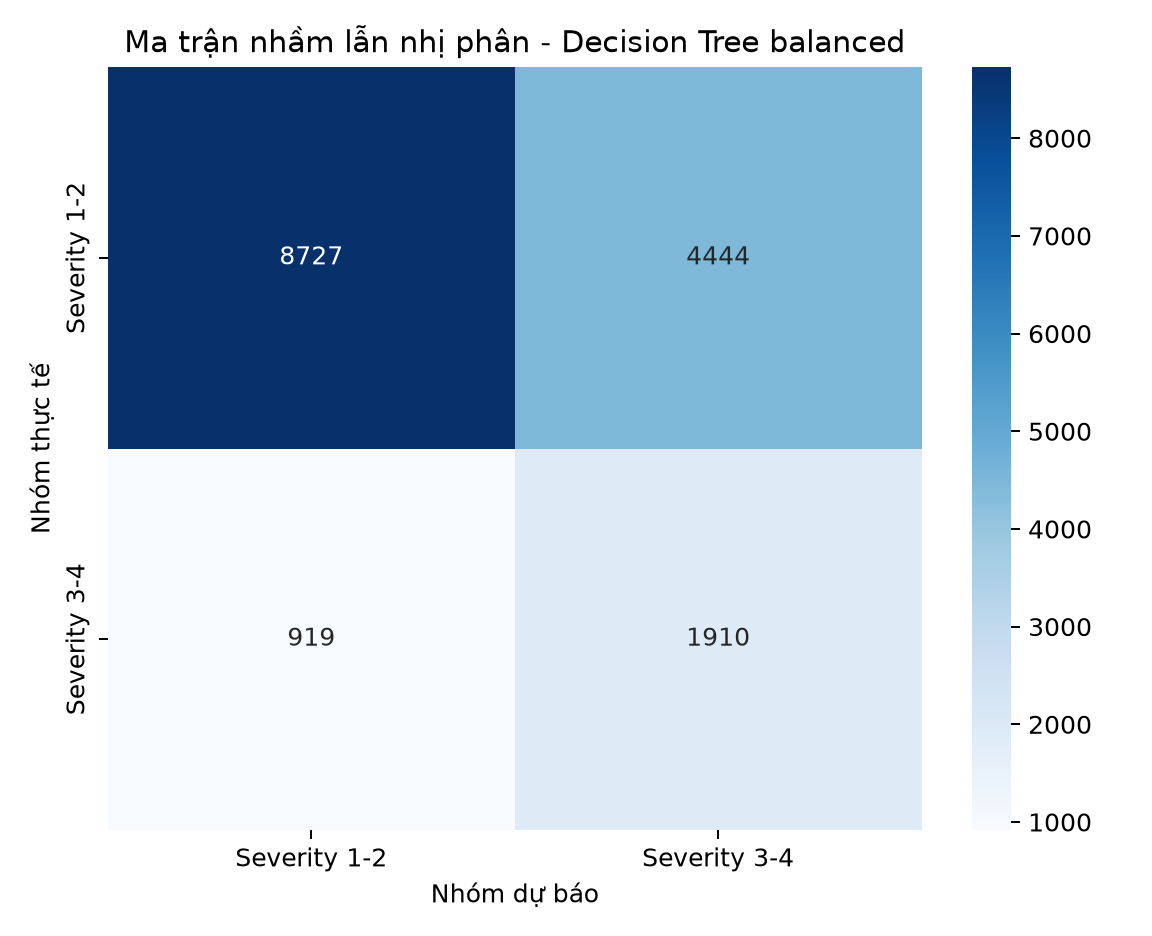

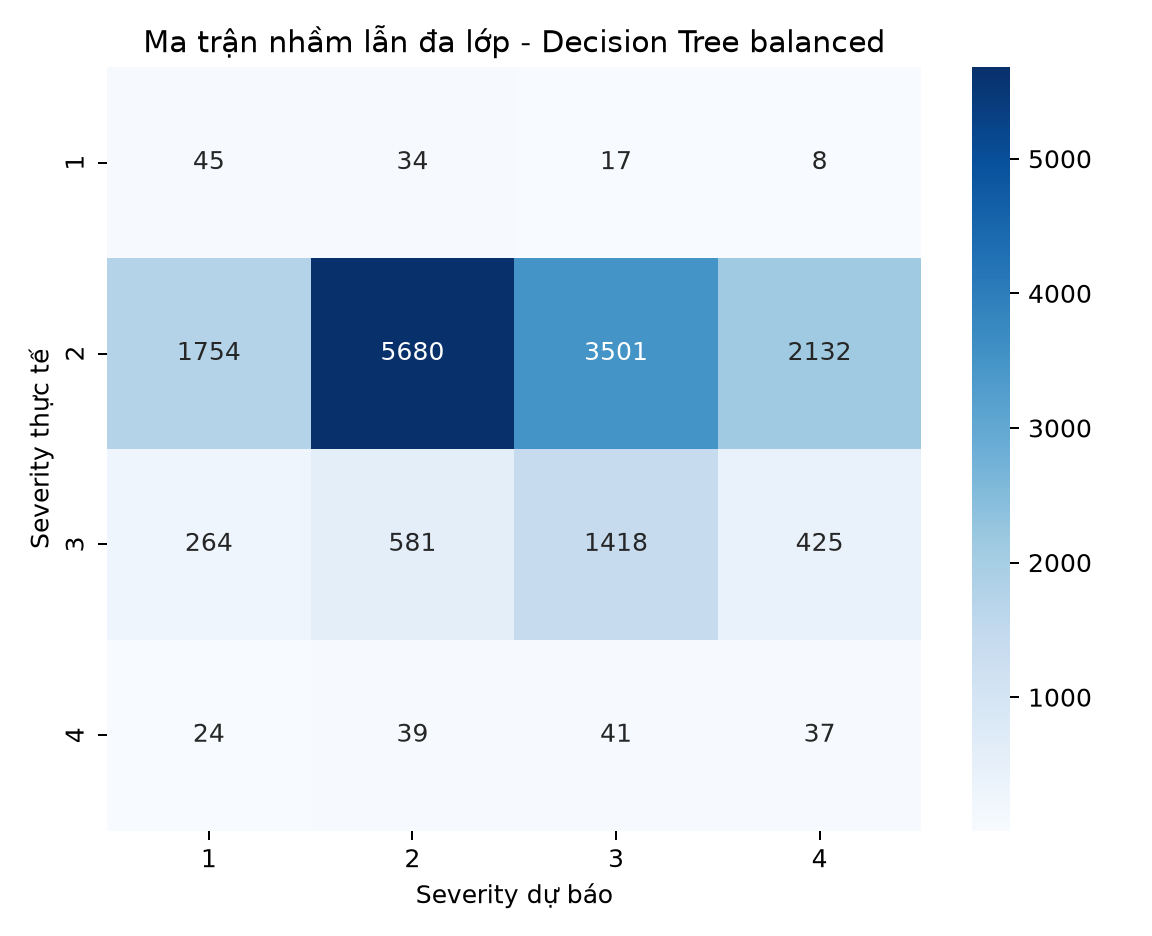

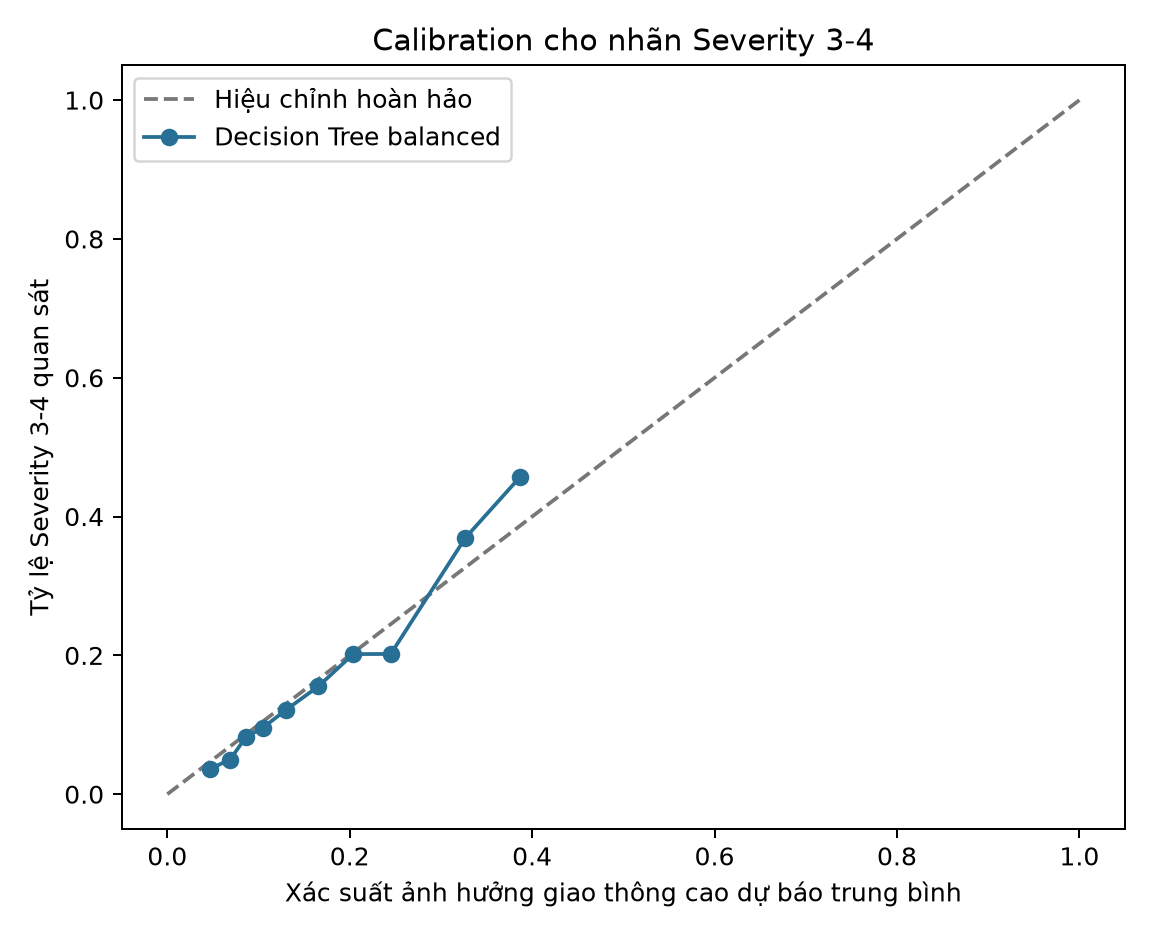

False negative severe: 919
False positive severe: 4444


In [3]:
classification_metrics, predictions, baseline_models, search_summary = run_baseline_classification(data_with_split)

metric_columns = [
    'model', 'best_cv_average_precision', 'average_precision', 'balanced_accuracy',
    'precision_severe', 'recall_severe', 'f1_severe', 'brier_severe'
]
display(classification_metrics[metric_columns].style.format(precision=4, na_rep='-'))
multiclass_metrics = pd.read_csv(ARTIFACT_DIR / 'classification_metrics_multiclass.csv')
display(multiclass_metrics[['model', 'best_cv_f1_macro', 'accuracy', 'balanced_accuracy', 'f1_macro', 'recall_s1', 'recall_s2', 'recall_s3', 'recall_s4']].style.format(precision=4, na_rep='-'))
display(pd.Series(search_summary, name='giá trị').to_frame())
display(Image(filename=str(FIGURE_DIR / 'confusion_matrix_baseline.png')))
display(Image(filename=str(FIGURE_DIR / 'confusion_matrix_multiclass.png')))
display(Image(filename=str(FIGURE_DIR / 'calibration_baseline.png')))

print('False negative severe:', int(predictions['is_false_negative_severe'].sum()))
print('False positive severe:', int(predictions['is_false_positive_severe'].sum()))

## 3. Luật kết hợp được chọn hoàn toàn trên train

Transaction kế thừa các ngưỡng cố định của Bài 1: hạ tầng, khung giờ, loại ngày, nhóm nhiệt độ, nhóm thời tiết, ánh sáng và mức độ ảnh hưởng giao thông. Thời gian thiếu trở thành item `Unknown`, không bị coi là ngày thường; luật chứa `Unknown` không được chọn. Test chưa tham gia sinh, lọc hoặc xếp hạng luật.

In [4]:
rules_train, rule_threshold_summary, train_transactions, test_transactions = mine_training_rules(data_with_split)

display(rule_threshold_summary.style.format({'runtime_seconds': '{:.2f}'}))
display(rules_train[['rule_id', 'antecedents', 'support_train', 'confidence_train', 'lift_train']].style.format({
    'support_train': '{:.4f}', 'confidence_train': '{:.4f}', 'lift_train': '{:.4f}'
}))

assert train_transactions.index.is_unique
assert test_transactions.index.is_unique
assert list(train_transactions.columns) == list(test_transactions.columns)
print('Train transactions:', train_transactions.shape)
print('Test transactions:', test_transactions.shape)

,min_support,frequent_itemsets,all_rules,rules_to_severe,runtime_seconds
0,0.010000,1242,5298,55,0.23
1,0.030000,521,2388,10,0.20


,rule_id,antecedents,support_train,confidence_train,lift_train
4845,R01,"[""Junction"", ""NhietDo_Vua""]",0.0112,0.2688,1.5204
3715,R02,"[""LoaiNgay_CuoiTuan"", ""ThoiTiet_Nhieu_May""]",0.0128,0.2575,1.4564
3724,R03,"[""AnhSang_Day"", ""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",0.0121,0.2573,1.4552
4215,R04,"[""GioTrongNgay_Sang"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0135,0.2553,1.4438
4848,R05,"[""AnhSang_Day"", ""Junction"", ""LoaiNgay_NgayThuong""]",0.0122,0.2519,1.4243
4839,R06,"[""Junction"", ""LoaiNgay_NgayThuong""]",0.0177,0.2499,1.4132
4022,R07,"[""GioTrongNgay_Trua_Chieu"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0119,0.2445,1.3826
3985,R08,"[""LoaiNgay_NgayThuong"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0300,0.2433,1.3762
3710,R09,"[""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",0.0169,0.2429,1.3739
4841,R10,"[""AnhSang_Day"", ""Junction""]",0.0150,0.2422,1.3695


Train transactions: (64000, 33)
Test transactions: (16000, 33)


## 4. Tổng hợp rules-model trên cùng test set

Các antecedent đã khóa bằng train được áp lên test. Bảng dưới so sánh tỷ lệ Severity 3-4 quan sát, lift, risk model và nhóm đối chứng. Quan hệ được gọi là `đồng hướng`, không phải xác nhận độc lập; độ ổn định còn được kiểm tra riêng theo Source, State và năm.

,rule_id,antecedents,n_test_covered,coverage_test,severe_rate_test,severe_rate_comparison,lift_test,risk_severe_model_mean,risk_severe_model_comparison,model_risk_difference,precision_severe_in_rule,recall_severe_in_rule,false_negative_severe_in_rule,false_positive_severe_in_rule,false_positive_rate_in_rule,false_positive_rate_comparison,n_eligible_main_strata,n_positive_main_strata,relation
0,R01,"[""Junction"", ""NhietDo_Vua""]",662,4.14%,25.83%,17.33%,1.461,23.06%,17.39%,5.66%,33.07%,73.68%,45,255,51.93%,33.04%,3,3,Đồng hướng và ổn định ở các tầng chính
1,R02,"[""LoaiNgay_CuoiTuan"", ""ThoiTiet_Nhieu_May""]",851,5.32%,24.32%,17.31%,1.376,19.37%,17.53%,1.84%,39.94%,66.18%,70,206,31.99%,33.83%,4,4,Đồng hướng và ổn định ở các tầng chính
2,R03,"[""AnhSang_Day"", ""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",755,4.72%,26.49%,17.24%,1.498,20.01%,17.51%,2.50%,39.24%,62.00%,76,192,34.59%,33.70%,4,4,Đồng hướng và ổn định ở các tầng chính
3,R04,"[""GioTrongNgay_Sang"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",798,4.99%,24.69%,17.31%,1.396,22.62%,17.36%,5.26%,33.26%,77.16%,45,305,50.75%,32.93%,4,3,"Đồng hướng trên mẫu gộp, không ổn định theo tầng"
4,R05,"[""AnhSang_Day"", ""Junction"", ""LoaiNgay_NgayThuong""]",734,4.59%,24.66%,17.35%,1.395,22.49%,17.39%,5.10%,31.18%,74.59%,46,298,53.89%,32.86%,4,4,Đồng hướng và ổn định ở các tầng chính
5,R06,"[""Junction"", ""LoaiNgay_NgayThuong""]",1085,6.78%,24.79%,17.16%,1.402,21.88%,17.32%,4.56%,33.67%,73.98%,70,392,48.04%,32.80%,4,4,Đồng hướng và ổn định ở các tầng chính
6,R07,"[""GioTrongNgay_Trua_Chieu"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",790,4.94%,23.04%,17.40%,1.303,21.42%,17.43%,3.99%,30.25%,73.63%,48,309,50.82%,32.91%,4,4,Đồng hướng và ổn định ở các tầng chính
7,R08,"[""LoaiNgay_NgayThuong"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",1935,12.09%,24.81%,16.70%,1.403,22.38%,16.97%,5.41%,32.44%,78.12%,105,781,53.68%,31.26%,4,3,"Đồng hướng trên mẫu gộp, không ổn định theo tầng"
8,R09,"[""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",1134,7.09%,25.49%,17.09%,1.441,19.94%,17.45%,2.49%,40.09%,65.05%,101,281,33.25%,33.77%,4,4,Đồng hướng và ổn định ở các tầng chính
9,R10,"[""AnhSang_Day"", ""Junction""]",946,5.91%,24.74%,17.24%,1.399,21.44%,17.39%,4.05%,32.88%,72.22%,65,345,48.46%,32.90%,4,4,Đồng hướng và ổn định ở các tầng chính


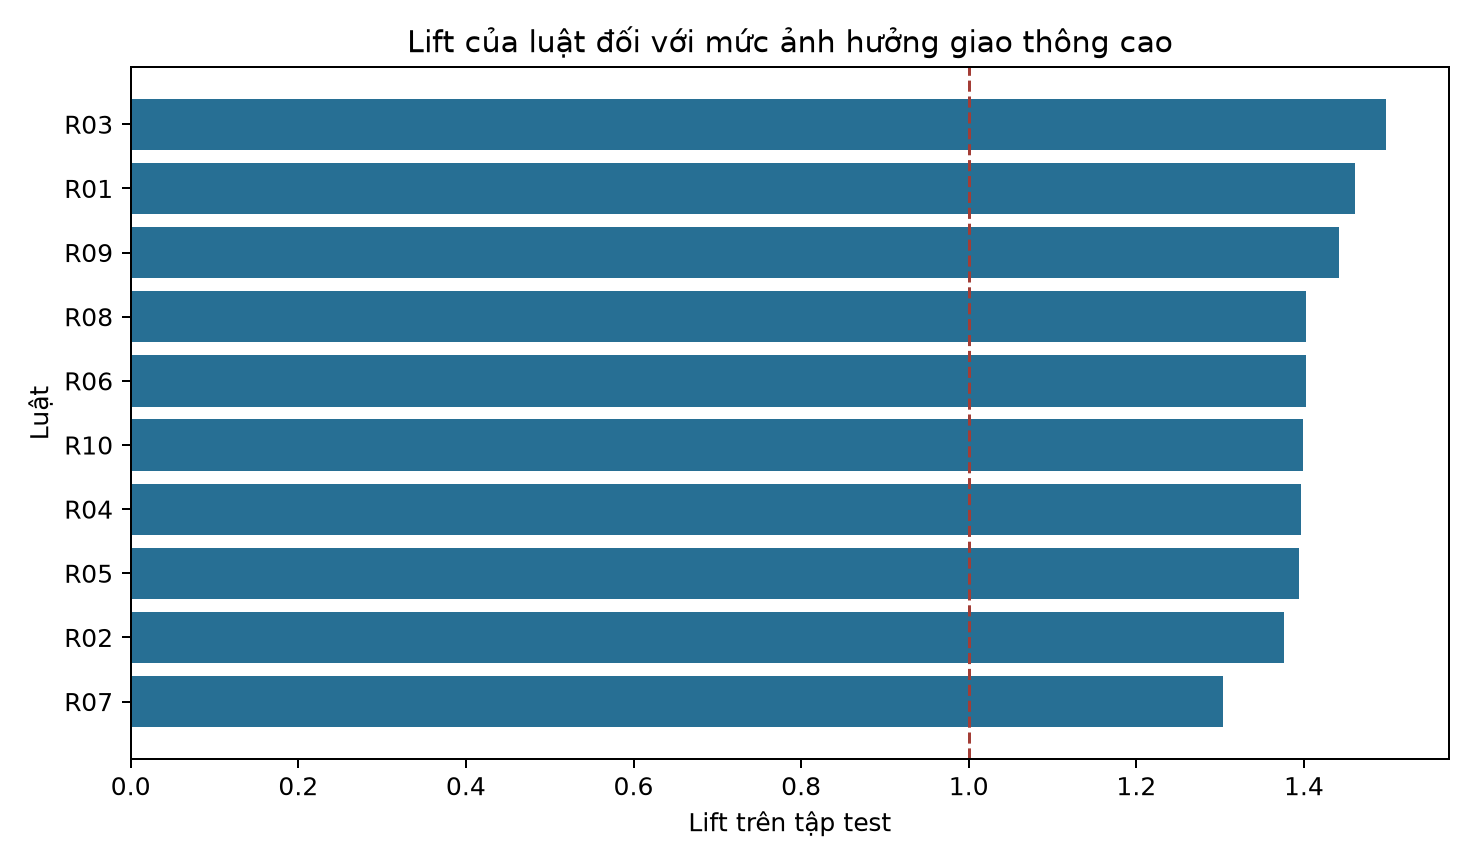

,rule_id,dimension,stratum,n_stratum,n_rule_group,n_comparison_group,severe_rate_rule,severe_rate_comparison,observed_rate_difference,model_risk_rule,model_risk_comparison,model_risk_difference,eligible_main_stratum
0,R01,Source,Source1,9146,397,8749,7.81%,4.32%,3.49%,0.200980,0.138223,6.28%,True
1,R01,Source,Source2,6481,248,6233,52.82%,34.70%,18.12%,0.281008,0.225259,5.57%,True
3,R01,State,CA,11965,581,11384,24.44%,15.79%,8.65%,0.233467,0.168883,6.46%,True
14,R02,Source,Source1,9146,480,8666,5.00%,4.44%,0.56%,0.141542,0.140915,0.06%,True
15,R02,Source,Source2,6481,352,6129,49.43%,34.59%,14.84%,0.268414,0.225037,4.34%,True
17,R02,State,CA,11965,645,11320,22.64%,15.85%,6.79%,0.192003,0.170880,2.11%,True
18,R02,State,TX,4035,206,3829,29.61%,21.62%,7.99%,0.198872,0.188316,1.06%,True
27,R03,Source,Source1,9146,429,8717,5.36%,4.43%,0.93%,0.157357,0.140140,1.72%,True
28,R03,Source,Source2,6481,312,6169,54.81%,34.41%,20.39%,0.259511,0.225768,3.37%,True
30,R03,State,CA,11965,637,11328,24.96%,15.72%,9.24%,0.201191,0.170379,3.08%,True


Đã lưu bảng trung tâm: D:\nhom-3-do-an\artifacts\rules_model_test.csv


In [5]:
rules_model_test, rules_stratified = integrate_rules_and_model(rules_train, test_transactions, predictions)

integration_columns = [
    'rule_id', 'antecedents', 'n_test_covered', 'coverage_test',
    'severe_rate_test', 'severe_rate_comparison', 'lift_test',
    'risk_severe_model_mean', 'risk_severe_model_comparison', 'model_risk_difference',
    'precision_severe_in_rule', 'recall_severe_in_rule',
    'false_negative_severe_in_rule', 'false_positive_severe_in_rule',
    'false_positive_rate_in_rule', 'false_positive_rate_comparison',
    'n_eligible_main_strata', 'n_positive_main_strata', 'relation'
]
display(rules_model_test[integration_columns].style.format({
    'coverage_test': '{:.2%}',
    'severe_rate_test': '{:.2%}',
    'severe_rate_comparison': '{:.2%}',
    'lift_test': '{:.3f}',
    'risk_severe_model_mean': '{:.2%}',
    'risk_severe_model_comparison': '{:.2%}',
    'model_risk_difference': '{:.2%}',
    'precision_severe_in_rule': '{:.2%}',
    'recall_severe_in_rule': '{:.2%}',
    'false_positive_rate_in_rule': '{:.2%}',
    'false_positive_rate_comparison': '{:.2%}',
}))
display(Image(filename=str(FIGURE_DIR / 'rule_lift_test.png')))
display(rules_stratified[rules_stratified['eligible_main_stratum']].style.format({'severe_rate_rule': '{:.2%}', 'severe_rate_comparison': '{:.2%}', 'observed_rate_difference': '{:.2%}', 'model_risk_difference': '{:.2%}'}))

assert rules_model_test['n_test_covered'].gt(0).all()
assert rules_model_test['rule_id'].is_unique
assert set(rules_stratified['rule_id']) == set(rules_model_test['rule_id'])
print('Đã lưu bảng trung tâm:', ARTIFACT_DIR / 'rules_model_test.csv')

## 5. Bàn giao cho các phần tiếp theo

- Sau D.6, Q1 đã có câu trả lời kỹ thuật; Q3 đã được trả lời với baseline; Q2 đã có baseline nhưng chưa phải kết luận mô hình cuối.
- `rules_model_test.csv` chứa precision, recall, số false negative, số false positive và false-positive rate theo từng nhóm luật; các nhóm có thể chồng lấp nên không cộng số lỗi giữa các dòng.
- Bước tiếp theo dùng `model_predictions_baseline.csv` và `rules_model_test.csv` để phân tích false negatives và so sánh Balanced Random Forest.
- `data_bias_audit.csv` và `rules_stratified_robustness.csv` là điều kiện bắt buộc khi chọn evidence cards; kết quả gộp một mình chưa đủ.
- Bảng rules-model cùng kết quả nâng cao là đầu vào để lập evidence cards; không được xem mỗi dòng là insight hoàn chỉnh.
- Các con số dùng trong báo cáo phải lấy trực tiếp từ artifact/notebook, không gõ lại thủ công.
- Kết luận nhân quả không thuộc phạm vi thiết kế này.

## 6. Phân tích lỗi của mô hình nhị phân đã chọn

Trước khi thử kỹ thuật nâng cao, cần chỉ ra hạn chế của baseline bằng số cụ thể trên **is_severe**
(không phải trên `Severity` đa lớp), theo đúng chuỗi C4.1 bước 1 ("Hạn chế"). Model được chọn
(theo `baseline_search_summary.json`, Average Precision CV cao nhất trên train) là **Decision Tree
balanced** trong lần chạy gần nhất — số liệu sẽ thay đổi nếu chạy lại trên artifact mới.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from do_an.analysis_core import INFRASTRUCTURE_ITEMS

error_analysis = predictions.merge(
    data_with_split.loc[data_with_split["split"] == "test", ["ID"] + CLASSIFICATION_FEATURES],
    on="ID",
    how="left",
    validate="one_to_one",
)

fn_mask = error_analysis["is_false_negative_severe"] == 1
fp_mask = error_analysis["is_false_positive_severe"] == 1
df_fn = error_analysis[fn_mask]
df_correct_severe = error_analysis[(error_analysis["is_severe"] == 1) & (~fn_mask)]

n_severe_true = (error_analysis["is_severe"] == 1).sum()
n_nonsevere_true = (error_analysis["is_severe"] == 0).sum()

error_summary = pd.DataFrame({
    "chỉ tiêu": [
        "Model được chọn", "Tổng test set", "Severity 3-4 thật", "Severity 1-2 thật",
        "False negative (bỏ sót 3-4)", "Tỷ lệ bỏ sót trong nhóm 3-4",
        "False positive (báo động giả)", "Tỷ lệ báo động giả trong nhóm 1-2",
    ],
    "giá trị": [
        search_summary["selected_model"], len(error_analysis), n_severe_true, n_nonsevere_true,
        int(fn_mask.sum()), fn_mask.sum() / max(n_severe_true, 1),
        int(fp_mask.sum()), fp_mask.sum() / max(n_nonsevere_true, 1),
    ],
})
display(error_summary)

infra_comparison = pd.DataFrame({
    "Tỷ lệ trong false negative": df_fn[INFRASTRUCTURE_ITEMS].mean(),
    "Tỷ lệ trong severe nhận diện đúng": df_correct_severe[INFRASTRUCTURE_ITEMS].mean(),
})
infra_comparison["Chênh lệch"] = (
    infra_comparison["Tỷ lệ trong false negative"] - infra_comparison["Tỷ lệ trong severe nhận diện đúng"]
)
display(infra_comparison.sort_values("Chênh lệch", ascending=False).style.format("{:.2%}"))

fn_by_source = error_analysis.groupby("Source", observed=True).apply(
    lambda g: pd.Series({
        "n_severe": (g["is_severe"] == 1).sum(),
        "n_false_negative": (g["is_false_negative_severe"] == 1).sum(),
        "fn_rate_trong_severe": g["is_false_negative_severe"].sum() / max((g["is_severe"] == 1).sum(), 1),
    }),
    include_groups=False,
)
display(fn_by_source.style.format({"fn_rate_trong_severe": "{:.2%}"}))


,chỉ tiêu,giá trị
0,Model được chọn,Decision Tree balanced
1,Tổng test set,16000
2,Severity 3-4 thật,2829
3,Severity 1-2 thật,13171
4,False negative (bỏ sót 3-4),919
5,Tỷ lệ bỏ sót trong nhóm 3-4,0.32485
6,False positive (báo động giả),4444
7,Tỷ lệ báo động giả trong nhóm 1-2,0.337408


,Tỷ lệ trong false negative,Tỷ lệ trong severe nhận diện đúng,Chênh lệch
Traffic_Signal,14.91%,3.77%,11.14%
Crossing,7.51%,0.68%,6.83%
Stop,3.26%,0.21%,3.05%
Give_Way,1.31%,0.26%,1.04%
Station,2.18%,1.26%,0.92%
Amenity,0.76%,0.16%,0.60%
No_Exit,0.22%,0.00%,0.22%
Bump,0.11%,0.00%,0.11%
Traffic_Calming,0.11%,0.00%,0.11%
Roundabout,0.00%,0.00%,0.00%


,n_severe,n_false_negative,fn_rate_trong_severe
Source,,,
Source1,409.000000,130.000000,31.78%
Source2,2294.000000,714.000000,31.12%
Source3,126.000000,75.000000,59.52%


## 7. Balanced Random Forest — kỹ thuật nâng cao cho lớp hiếm

Hạn chế đã xác nhận ở Mục 6 và trong `classification_metrics.csv`/`muc_3_tong_hop_lien_ky_thuat.md`:
model nhị phân bỏ sót 919/2.829 mẫu Severity 3-4 trên toàn snapshot (số liệu trên tập test đầy đủ 16.000 dòng;
số liệu chạy trong notebook này có thể khác nếu chạy trên máy khác hoặc dữ liệu con).
Balanced Random Forest được chọn vì lấy mẫu cân bằng trong từng cây, xử lý trực tiếp mất cân bằng lớp
17,68% mà không cần tối ưu accuracy đơn thuần.

**Nguyên tắc bắt buộc:** dùng **đúng** split, feature whitelist (`CLASSIFICATION_FEATURES`, đã loại `Distance(mi)`)
và tiêu chí Average Precision CV như baseline; test chỉ đánh giá **một lần duy nhất** sau khi khóa tham số.


**Mục tiêu cụ thể:** cải thiện khả năng nhận diện Severity 3-4 (đo bằng Average Precision
và recall lớp dương) so với baseline, chấp nhận đánh đổi ở precision/số false positive —
không phải tối đa hóa accuracy tổng thể.

**Cơ chế và giả định:** ở mỗi cây, BRF lấy toàn bộ mẫu lớp thiểu số (Severity 3-4) và
bootstrap cùng số lượng mẫu từ lớp đa số (Severity 1-2), thay vì bootstrap trên toàn bộ
dữ liệu gốc như Random Forest chuẩn; cây sau đó được huấn luyện trên mẫu đã cân bằng bằng
CART với random feature selection tại mỗi node [1]. Giả định ngầm: lớp thiểu số đủ đa dạng
để từng cây học được ranh giới quyết định hợp lý dù bị undersample lặp lại, và việc kết hợp
nhiều cây với các mẫu majority khác nhau mỗi lần sẽ bù lại phần thông tin lớp đa số bị bỏ bớt.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
)
from imblearn.ensemble import BalancedRandomForestClassifier
import time

from do_an.analysis_core import RANDOM_STATE, GRID_SEARCH_JOBS

train_mask = data_with_split["split"] == "train"
test_mask = data_with_split["split"] == "test"

X_train = data_with_split.loc[train_mask, CLASSIFICATION_FEATURES]
y_train = data_with_split.loc[train_mask, "is_severe"]
X_test = data_with_split.loc[test_mask, CLASSIFICATION_FEATURES]
y_test = data_with_split.loc[test_mask, "is_severe"]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Tỷ lệ is_severe=1 trong train:", round(y_train.mean(), 4))


Train: (64000, 21)  Test: (16000, 21)
Tỷ lệ is_severe=1 trong train: 0.1768


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

brf_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        sampling_strategy="all",
        replacement=True,
        bootstrap=False,
    )),
])

brf_search = GridSearchCV(
    brf_pipeline,
    {
        "model__n_estimators": [200, 400],
        "model__max_depth": [8, 12],
        "model__min_samples_leaf": [20, 50, 100],
    },
    scoring="average_precision",
    cv=cv,
    n_jobs=GRID_SEARCH_JOBS,
)

t0 = time.time()
brf_search.fit(X_train, y_train)
fit_time = time.time() - t0

print("Tham số BRF tốt nhất (theo AP CV trên train, KHÔNG phải test):", brf_search.best_params_)
print(f"AP CV tốt nhất: {brf_search.best_score_:.4f}")
print(f"Thời gian tuning: {fit_time:.1f}s")


Tham số BRF tốt nhất (theo AP CV trên train, KHÔNG phải test): {'model__max_depth': 12, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
AP CV tốt nhất: 0.3550
Thời gian tuning: 571.3s


In [9]:
best_brf = brf_search.best_estimator_

calibrated_brf = CalibratedClassifierCV(best_brf, method="sigmoid", cv=5)
t0 = time.time()
calibrated_brf.fit(X_train, y_train)
predict_time = time.time() - t0

severe_index = list(calibrated_brf.classes_).index(1)
risk_severe_brf = calibrated_brf.predict_proba(X_test)[:, severe_index]
is_pred_severe_brf = best_brf.predict(X_test)

ap_brf = average_precision_score(y_test, risk_severe_brf)
roc_auc_brf = roc_auc_score(y_test, risk_severe_brf)
brier_brf = brier_score_loss(y_test, risk_severe_brf)
precision_brf = precision_score(y_test, is_pred_severe_brf, zero_division=0)
recall_brf = recall_score(y_test, is_pred_severe_brf, zero_division=0)
f1_brf = f1_score(y_test, is_pred_severe_brf, zero_division=0)
bal_acc_brf = balanced_accuracy_score(y_test, is_pred_severe_brf)

print("=== Balanced Random Forest — kết quả TEST (chạy đúng 1 lần) ===")
print(classification_report(y_test, is_pred_severe_brf, digits=3))
cm_brf = confusion_matrix(y_test, is_pred_severe_brf, labels=[0, 1])
print("Confusion matrix:\n", cm_brf)
print(f"AP: {ap_brf:.4f} | ROC AUC: {roc_auc_brf:.4f} | Brier: {brier_brf:.4f}")
print(f"Precision: {precision_brf:.4f} | Recall: {recall_brf:.4f} | F1: {f1_brf:.4f} | Balanced acc: {bal_acc_brf:.4f}")

output_brf = data_with_split.loc[test_mask, ["ID", "Source", "State", "Accident_Year"]].copy()
output_brf["is_severe"] = y_test.values
output_brf["risk_severe"] = risk_severe_brf
output_brf["is_pred_severe"] = is_pred_severe_brf
output_brf["is_false_negative_severe"] = (
    (output_brf["is_severe"] == 1) & (output_brf["is_pred_severe"] == 0)
).astype("int8")
output_brf["is_false_positive_severe"] = (
    (output_brf["is_severe"] == 0) & (output_brf["is_pred_severe"] == 1)
).astype("int8")
output_brf.to_csv(ARTIFACT_DIR / "model_predictions_brf.csv", index=False)
print(f"\nĐã lưu: {ARTIFACT_DIR / 'model_predictions_brf.csv'}")

plt.figure(figsize=(6.4, 5.2))
sns.heatmap(
    cm_brf, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Severity 1-2", "Severity 3-4"], yticklabels=["Severity 1-2", "Severity 3-4"],
)
plt.title("Ma trận nhầm lẫn nhị phân - Balanced Random Forest")
plt.xlabel("Nhóm dự báo"); plt.ylabel("Nhóm thực tế")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix_brf.png", dpi=180)
plt.close()

observed_rate, predicted_rate = calibration_curve(y_test, risk_severe_brf, n_bins=10, strategy="quantile")
plt.figure(figsize=(6.4, 5.2))
plt.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Hiệu chỉnh hoàn hảo")
plt.plot(predicted_rate, observed_rate, marker="o", color="#c0392b", label="Balanced Random Forest")
plt.xlabel("Xác suất ảnh hưởng giao thông cao dự báo trung bình")
plt.ylabel("Tỷ lệ Severity 3-4 quan sát")
plt.title("Calibration - Balanced Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_brf.png", dpi=180)
plt.close()
print("Đã lưu confusion_matrix_brf.png và calibration_brf.png")


=== Balanced Random Forest — kết quả TEST (chạy đúng 1 lần) ===
              precision    recall  f1-score   support

           0      0.906     0.642     0.752     13171
           1      0.293     0.690     0.411      2829

    accuracy                          0.651     16000
   macro avg      0.599     0.666     0.581     16000
weighted avg      0.798     0.651     0.691     16000

Confusion matrix:
 [[8460 4711]
 [ 878 1951]]
AP: 0.3722 | ROC AUC: 0.7367 | Brier: 0.1301
Precision: 0.2929 | Recall: 0.6896 | F1: 0.4111 | Balanced acc: 0.6660

Đã lưu: D:\nhom-3-do-an\artifacts\model_predictions_brf.csv
Đã lưu confusion_matrix_brf.png và calibration_brf.png


### Bảng Before/After

So sánh baseline đã chọn (**Decision Tree balanced** theo bản chạy gần nhất) với Balanced Random Forest,
trên đúng cùng test set, cùng feature, cùng phương pháp calibration.


Cột Runtime của baseline để trống (NaN) vì thời gian train/predict không được đo trong
bước chọn mô hình ở D.4 (Bài 3); Runtime của BRF (608,2s) là số đo lần đầu ở D.7, gồm cả
GridSearchCV (`fit_time`) và calibration/predict (`predict_time`) — không dùng để so sánh
tốc độ hai mô hình, chỉ ghi nhận chi phí thực tế của BRF.

In [10]:
baseline_row = classification_metrics.loc[
    classification_metrics["model"] == search_summary["selected_model"]
].iloc[0]

before_after = pd.DataFrame([
    {
        "Mô hình": f"Baseline đã chọn ({search_summary['selected_model']})",
        "AP test": baseline_row["average_precision"],
        "ROC AUC": baseline_row["roc_auc"],
        "Precision (3-4)": baseline_row["precision_severe"],
        "Recall (3-4)": baseline_row["recall_severe"],
        "F1 (3-4)": baseline_row["f1_severe"],
        "Balanced accuracy": baseline_row["balanced_accuracy"],
        "Brier": baseline_row["brier_severe"],
        "False negative": int(predictions["is_false_negative_severe"].sum()),
        "False positive": int(predictions["is_false_positive_severe"].sum()),
        "Runtime (s)": np.nan,
    },
    {
        "Mô hình": "Balanced Random Forest",
        "AP test": ap_brf,
        "ROC AUC": roc_auc_brf,
        "Precision (3-4)": precision_brf,
        "Recall (3-4)": recall_brf,
        "F1 (3-4)": f1_brf,
        "Balanced accuracy": bal_acc_brf,
        "Brier": brier_brf,
        "False negative": int(output_brf["is_false_negative_severe"].sum()),
        "False positive": int(output_brf["is_false_positive_severe"].sum()),
        "Runtime (s)": round(fit_time + predict_time, 1),
    },
])
before_after.to_csv(ARTIFACT_DIR / "model_comparison_before_after.csv", index=False)
display(before_after.style.format({
    "AP test": "{:.4f}", "ROC AUC": "{:.4f}", "Precision (3-4)": "{:.4f}",
    "Recall (3-4)": "{:.4f}", "F1 (3-4)": "{:.4f}", "Balanced accuracy": "{:.4f}",
    "Brier": "{:.4f}", "Runtime (s)": "{:.1f}",
}))


,Mô hình,AP test,ROC AUC,Precision (3-4),Recall (3-4),F1 (3-4),Balanced accuracy,Brier,False negative,False positive,Runtime (s)
0,Baseline đã chọn (Decision Tree balanced),0.3668,0.7312,0.3006,0.6752,0.4160,0.6689,0.1290,919,4444,nan
1,Balanced Random Forest,0.3722,0.7367,0.2929,0.6896,0.4111,0.6660,0.1301,878,4711,608.2
